In [1]:
# Importation des biblothèques

import numpy as np
import matplotlib.pyplot as plt
import time
import scipy.sparse as sp

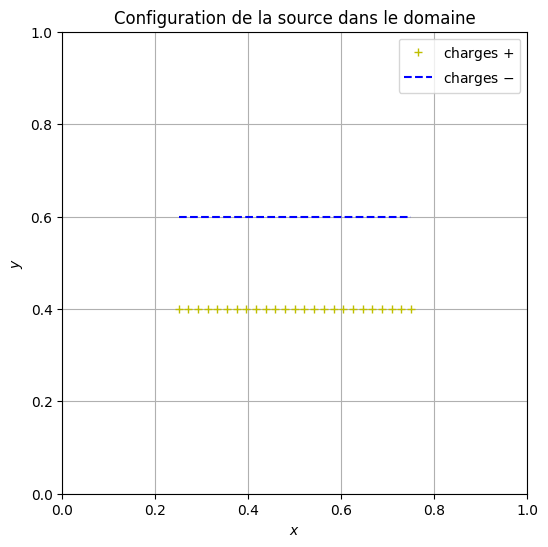

In [ ]:
# Modélisation du condensateur

x_lim = [0.25,0.75]
y_lim = [0.4,0.6]

n = 25

x_c = np.linspace(x_lim[0],x_lim[1],n)
y_c = [[y_lim[0] for x in range(n)],[y_lim[1] for x in range(n)]]

plt.figure(figsize = (6 ,6))
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Configuration de la source dans le domaine')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.xlim([0,1])
plt.ylim([0,1])
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Discrétisation

N = 65 # Nombre de points suivant un axe
I,J = N,N # Maillage carré

x0,y0 = 0,0
dx,dy = (1-x0)/I,(1-y0)/J

x = [x0+i*dx for i in range(I)]
y = [y0+i*dy for i in range(J)]

In [ ]:
# Construction de la matrice b

e0=8.854187*10**(-12) # la permittivité électrique du vide en F/m

rho = np.zeros((J,I)) # on initialise la matrice

m,M = int(y_lim[0]*J),int(y_lim[1]*J)
for i in range(int(x_lim[0]*I), int(x_lim[1]*I)):
  rho[M][i] = -(-e0) # charge négative
  rho[m][i] = -(+e0) # charge positive

b = [] # indexation à 1D

for j in range(J):
    for i in range(I):
        b.append([rho[j][i]])

In [ ]:
# Construction du laplacien matriciel

A = np.zeros((I*J, J*I))
for k in range(I*J):
  A[k][k] = -2*(dx**(-2)+dy**(-2))
  if k < J : # bords droit et gauche
    A[k][k+1] = dy**(-2)
    A[k+J][k] = dx**(-2)
    if k != 0 :
      A[k][k-1] = dy**(-2)
  elif k > I*J-J-1 : # bords haut et bas
    A[k][k-1] = dy**(-2)
    A[k-J][k] = dx**(-2)
    if k != I*J-1 :
      A[k][k+1] = dy**(-2)
  else :
    A[k][k-1] = dy**(-2)
    A[k][k+1] = dy**(-2)
    A[k-J][k] = dx**(-2)
    A[k+J][k] = dx**(-2)

In [ ]:
# Méthode d'intégration par le pivot de Gauss

def Gauss(A, b):
  Inverse = np.linalg.inv(A)
  return np.dot(Inverse, b)

start = time.time()
V_Gauss = Gauss(A, b)
end = time.time()
t_Gauss = end-start
erreur_Gauss = np.linalg.norm(np.dot(A,V_Gauss) - b)
print('Le temps de calcul par le pivot de Gauss est de', t_Gauss,'s.')
print("L'erreur en norme par le pivot de Gauss est de", erreur_Gauss,'.')

Le temps de calcul par le pivot de Gauss est de 8.674680709838867 s.
L'erreur en norme par le pivot de Gauss est de 1.4160996160375673e-24 .


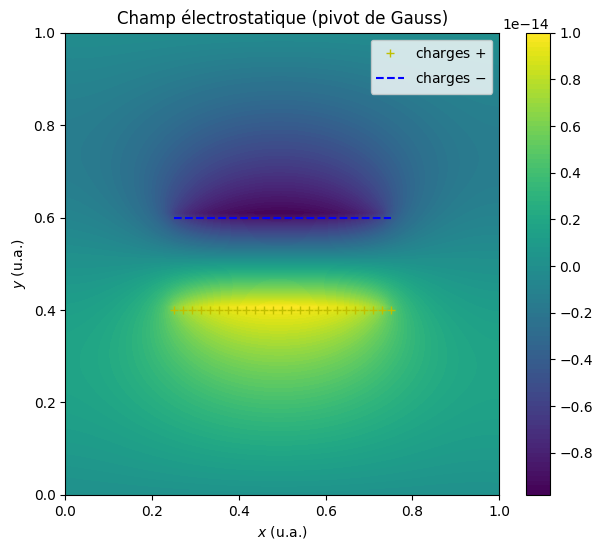

In [ ]:
# Affichage de la solution obtenue par pivot de Gauss

V_G = V_Gauss.reshape(I,J)

plt.figure(figsize = (7 ,6))
x = np.linspace(0,1,I)
y = np.linspace(0,1,J)
plt.contourf(x,y,V_G,100)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Champ électrostatique (pivot de Gauss)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()
plt.show()

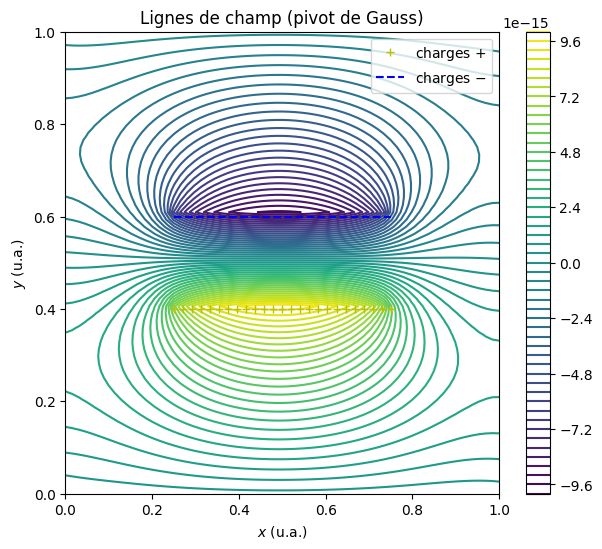

In [ ]:
# Affichage des lignes de champ

plt.figure(figsize = (7 ,6))
plt.contour(x,y,V_G,50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Lignes de champ (pivot de Gauss)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()
plt.show()

Text(0, 0.5, '$||AX-b||$')

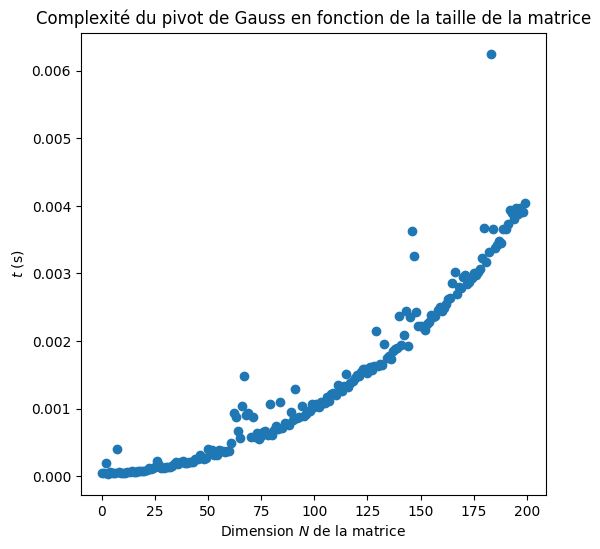

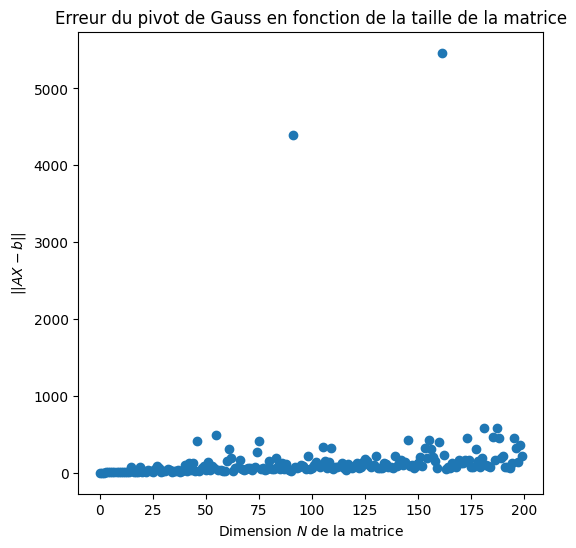

In [ ]:
# Évolution de la complexité avec la taille de la matrice

Temps = []
Erreur = []

for k in range(200):
  S = 0
  R = 0
  i = 0
  for n in range(10):
    i += 1
    start = time.time()
    a = np.random.uniform(size=(k, k))
    b = np.random.uniform(size=(k, 1))
    matrice = Gauss(np.random.uniform(size=(k, k)), np.random.uniform(size=(k, 1)))
    end = time.time()
    S += end-start
    R += np.linalg.norm(np.dot(a,matrice) - b)
  Temps.append(S/i)
  Erreur.append(R/i)

plt.figure(figsize = (6 ,6))
plt.scatter([i for i in range(200)],Temps,label='Temps')
plt.title('Complexité du pivot de Gauss en fonction de la taille de la matrice')
plt.xlabel('Dimension $N$ de la matrice')
plt.ylabel('$t$ (s)')
plt.figure(figsize = (6 ,6))
plt.scatter([i for i in range(200)],Erreur,label='Erreur')
plt.title('Erreur du pivot de Gauss en fonction de la taille de la matrice')
plt.xlabel('Dimension $N$ de la matrice')
plt.ylabel('$||AX-b||$')

In [ ]:
# Méthode des matrices très creuses

start = time.time()
V_creux = sp.linalg.spsolve(sp.csr_matrix(A),b)
end = time.time()

t_creux = end-start
erreur_creux = np.linalg.norm(np.dot(A,V_creux) - b)
print('Le temps de calcul par la méthode des matrices très creuses est de', t_creux,'s.')
print("L'erreur en norme par la méthode des matrices très creuses est de", erreur_creux,'.')

Le temps de calcul par la méthode des matrices très creuses est de 0.15999603271484375 s.
L'erreur en norme par la méthode des matrices très creuses est de 6.511289896378562e-09 .


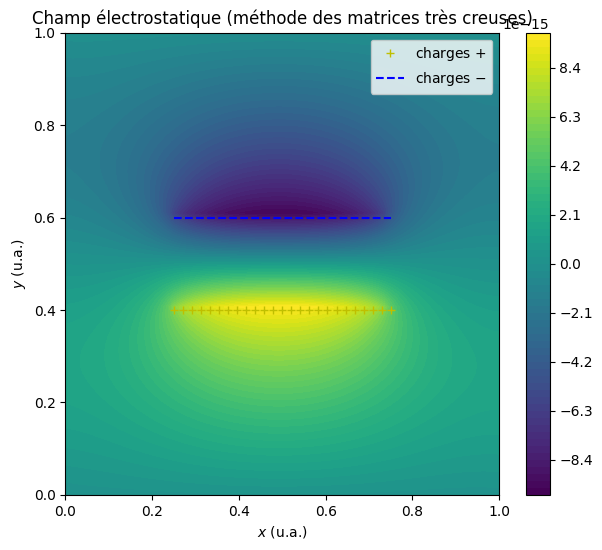

In [ ]:
# Affichage de la solution obtenue par la méthode des matrices très creuses

V_c = V_creux.reshape(I,J)

plt.figure(figsize = (7 ,6))
x = np.linspace(0,1,I)
y = np.linspace(0,1,J)
plt.contourf(x, y,V_c,65)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Champ électrostatique (méthode des matrices très creuses)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()
plt.show()

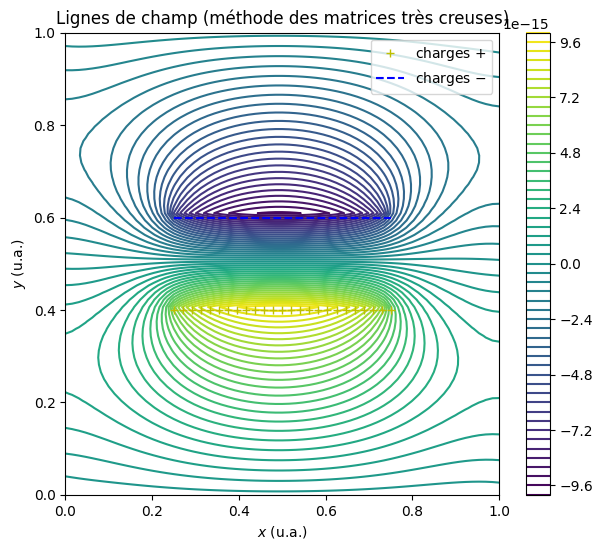

In [ ]:
# Affichage des lignes de champ

plt.figure(figsize = (7 ,6))
plt.contour(x,y,V_c,50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Lignes de champ (méthode des matrices très creuses)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()
plt.show()

In [ ]:
# Résolution numérique avec linalg.solve

start = time.time()
x_solve = np.linalg.solve(A, np.array(b))
end = time.time()
x_solve = np.array(x_solve)
V_solve = x_solve.flatten() # avoir le bon format pour le reshape

t_solve = end-start
erreur_solve = np.linalg.norm(np.dot(A,V_solve) - b)
print('Le temps de calcul par la méthode solve est de', t_solve,'s.')
print("L'erreur en norme par la méthode solve est de", erreur_solve,'.')

Le temps de calcul par la méthode solve est de 2.7101197242736816 s.
L'erreur en norme par la méthode solve est de 6.511289896378562e-09 .


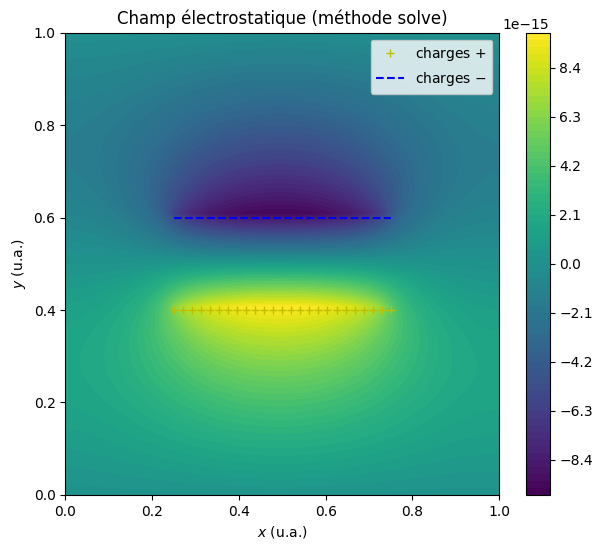

In [ ]:
V_s = V_solve.reshape(I,J)

plt.figure(figsize = (7 ,6))
x = np.linspace(0,1,I)
y = np.linspace(0,1,J)
plt.contourf(x,y,V_s,65)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Champ électrostatique (méthode solve)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()
plt.show()

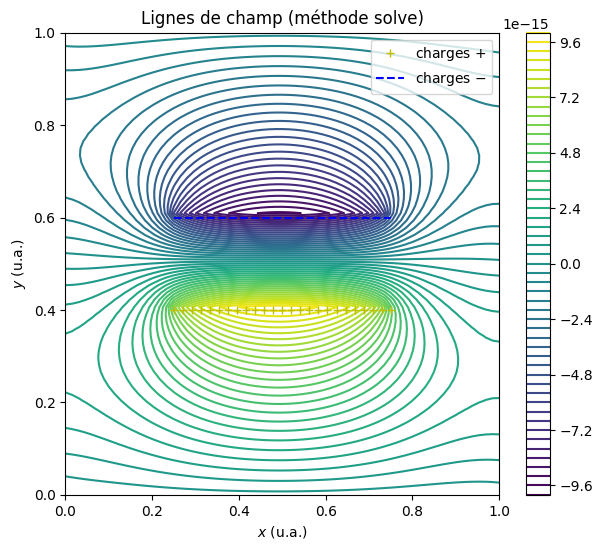

In [ ]:
# Affichage des lignes de champ

plt.figure(figsize = (7 ,6))
plt.contour(x,y,V_s,50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Lignes de champ (méthode solve)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()
plt.show()

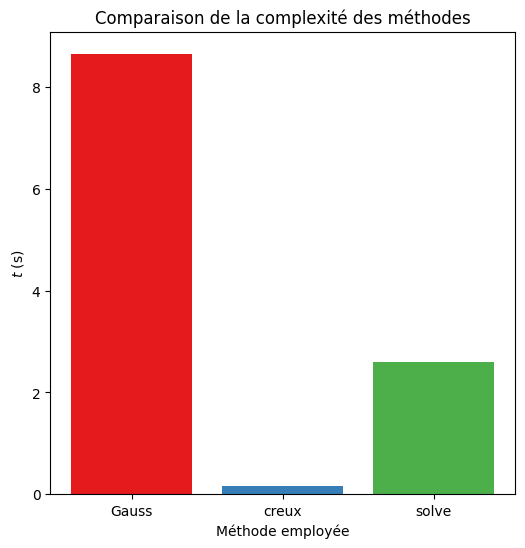

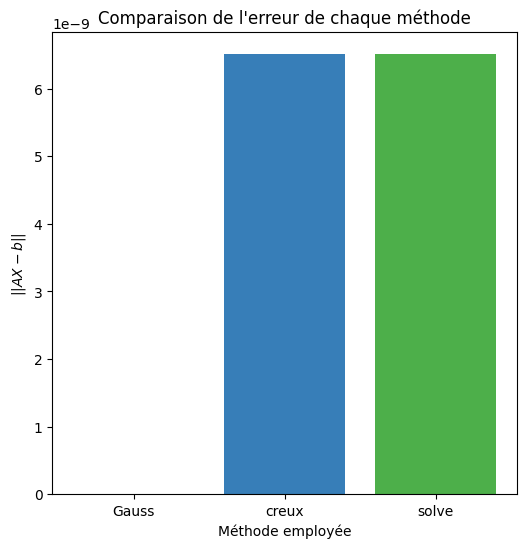

In [ ]:
# Comparaison des 3 méthodes directes

labels = ['Gauss', 'creux', 'solve']
T = [t_Gauss,t_creux,t_solve]
E = [erreur_Gauss,erreur_creux,erreur_solve]

# Utilisation de la palette de couleurs "Set2"
palette = plt.get_cmap("Set1")

plt.figure(1,figsize = (6 ,6))
plt.bar(labels,T, color=[palette(i) for i in range(len(labels))])
plt.title('Comparaison de la complexité des méthodes')
plt.xlabel('Méthode employée')
plt.ylabel('$t$ (s)')

plt.figure(2,figsize = (6 ,6))
plt.bar(labels,E, color=[palette(i) for i in range(len(labels))])
plt.title("Comparaison de l'erreur de chaque méthode")
plt.xlabel('Méthode employée')
plt.ylabel('$||AX-b||$')

plt.show()

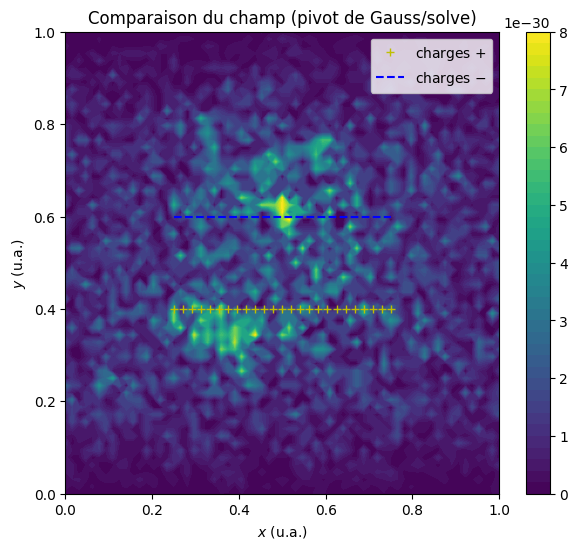

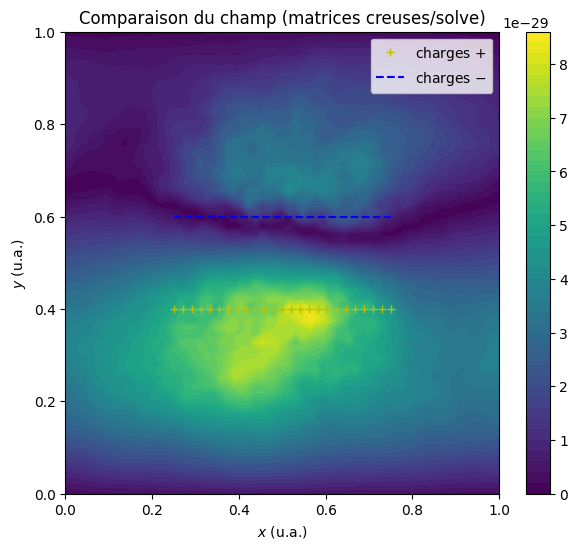

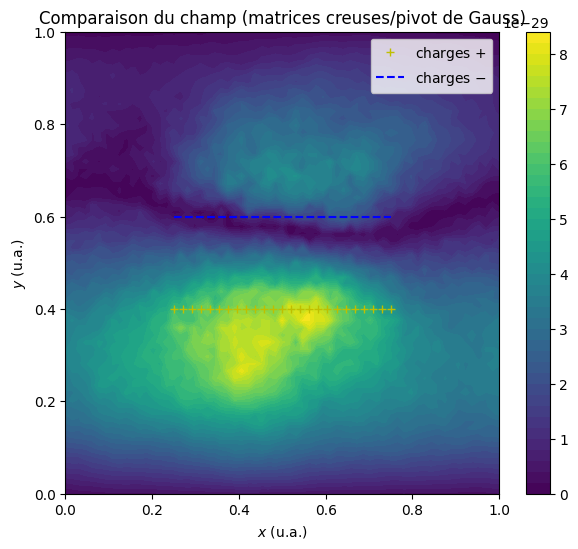

In [ ]:
plt.figure(figsize = (7 ,6))
plt.contourf(x,y,abs(V_s-V_G),50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Comparaison du champ (pivot de Gauss/solve)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()

plt.figure(figsize = (7 ,6))
plt.contourf(x,y,abs(V_c-V_s),50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Comparaison du champ (matrices creuses/solve)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()

plt.figure(figsize = (7 ,6))
plt.contourf(x,y,abs(V_c-V_G),50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Comparaison du champ (matrices creuses/pivot de Gauss)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()

plt.show()

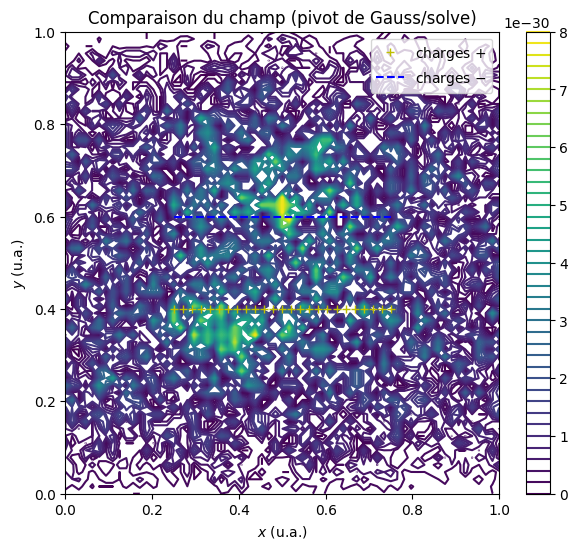

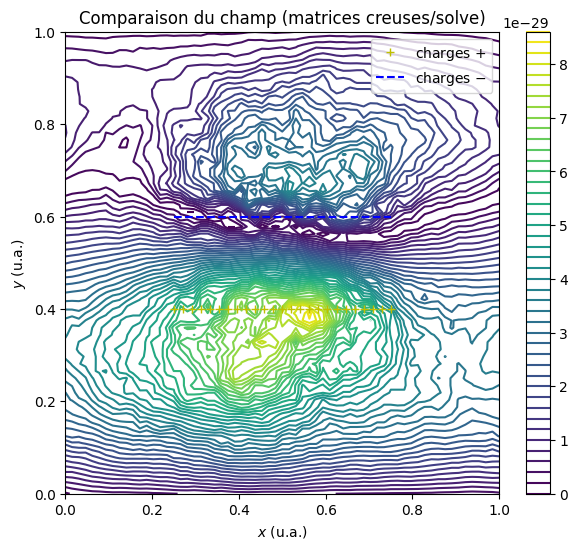

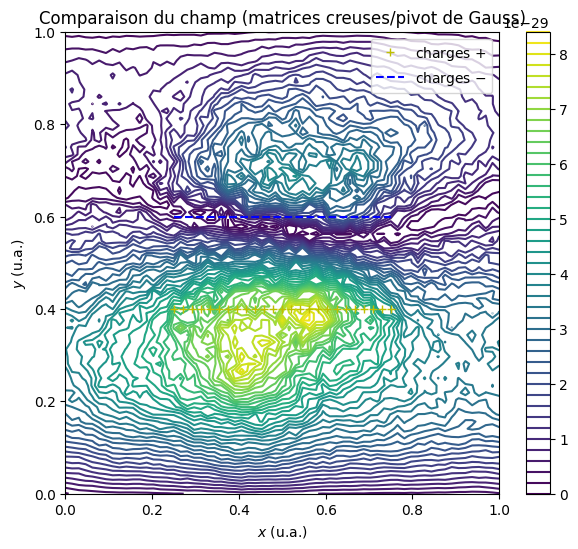

In [ ]:
plt.figure(figsize = (7 ,6))
plt.contour(x,y,abs(V_s-V_G),50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Comparaison du champ (pivot de Gauss/solve)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()

plt.figure(figsize = (7 ,6))
plt.contour(x,y,abs(V_c-V_s),50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Comparaison du champ (matrices creuses/solve)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()

plt.figure(figsize = (7 ,6))
plt.contour(x,y,abs(V_c-V_G),50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Comparaison du champ (matrices creuses/pivot de Gauss)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()

plt.show()

In [ ]:
# Méthode de Jacobi

def Jacobi(A, b, cvg, N_iter):
    n = len(b)
    V = np.zeros(n)  # Initialisation de la solution

    for k in range(N_iter):
      V_k = np.copy(V)
      for i in range(n):
        D = np.dot(A[i, :i], V_k[:i]) + np.dot(A[i, i+1:], V_k[i+1:])
        V[i] = (b[i] - D) / A[i, i]

      # Critère de convergence
      if np.linalg.norm(V_k - V, ord=np.inf) < cvg :
          return V_k,k+1

    return V,N_iter

start = time.time()
cvg = 1e-17
N_iter = 3000
V_Jacobi, N_Jacobi = Jacobi(A, b, cvg, N_iter)
end = time.time()
t_Jacobi = end-start
erreur_Jacobi = np.linalg.norm(np.dot(A,V_Jacobi) - b)
print('Le temps de calcul par la méthode de Jacobi est de', t_Jacobi,'s au bout de',N_Jacobi,'itérations pour une tolérance de',cvg,'.')
print("L'erreur en norme par la méthode de Jacobi est de", erreur_Jacobi,'.')

<ipython-input-20-feb5191f95e5>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V[i] = (b[i] - D) / A[i, i]


Le temps de calcul par la méthode de Jacobi est de 14.805980205535889 s au bout de 251 itérations pour une tolérance de 1e-17 .
L'erreur en norme par la méthode de Jacobi est de 6.477221414960976e-09 .


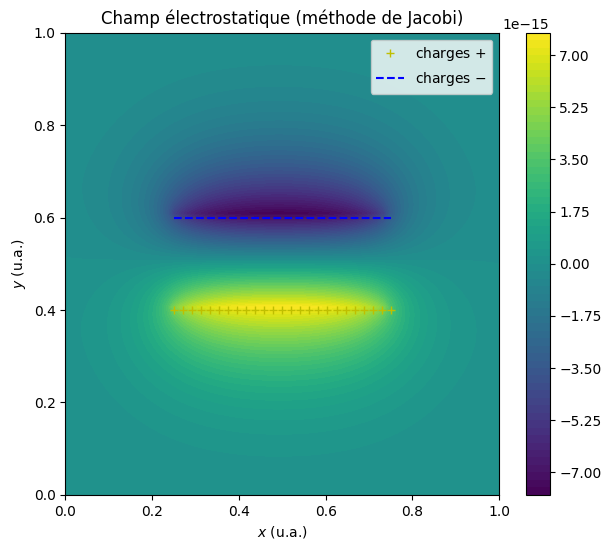

In [ ]:
# Affichage de la solution obtenue par la méthode de Jacobi

V_J = V_Jacobi.reshape(I,J)

plt.figure(figsize = (7 ,6))
x = np.linspace(0,1,65)
y = np.linspace(0,1,65)
plt.contourf(x,y,V_J,65)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Champ électrostatique (méthode de Jacobi)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()
plt.show()

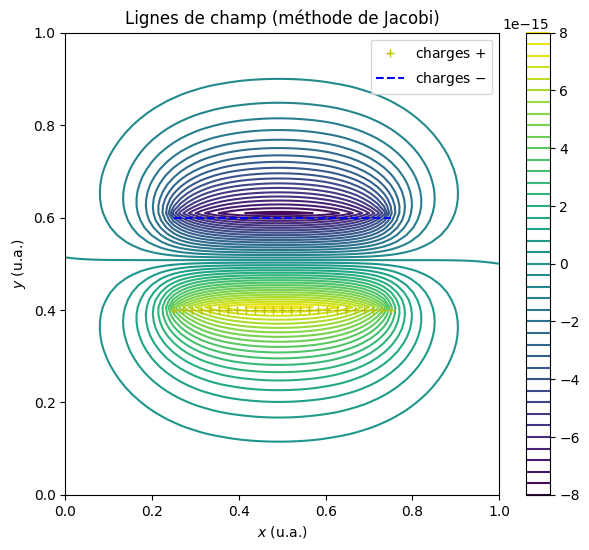

In [ ]:
# Affichage des lignes de champ

plt.figure(figsize = (7 ,6))
plt.contour(x,y,V_J,50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Lignes de champ (méthode de Jacobi)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()
plt.show()

<ipython-input-20-feb5191f95e5>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V[i] = (b[i] - D) / A[i, i]


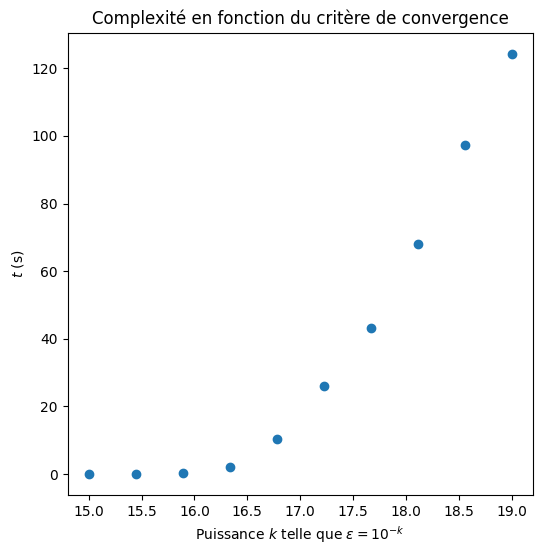

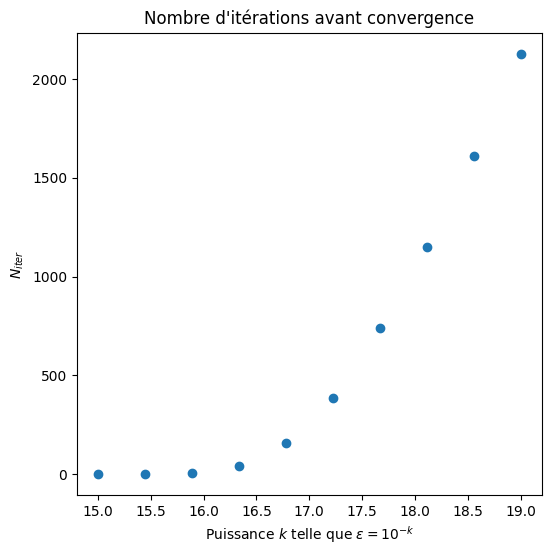

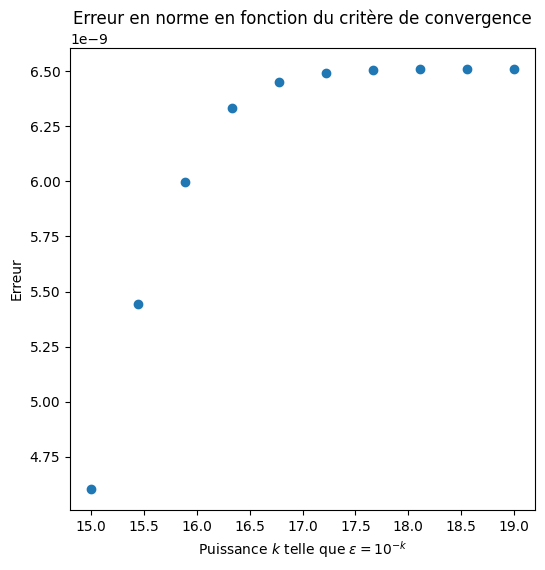

In [ ]:
# Évolution de la complexité en fonction du critère de convergence

N_iter = 5000
Temps_J = []
Erreur_J = []
N_J = []
i = np.linspace(15,19,10)

for j in i:
  cvg = 10**(-j)
  start = time.time()
  Z,N_fin = Jacobi(A, b, cvg, N_iter)
  end = time.time()
  Temps_J.append(end-start)
  N_J.append(N_fin)
  Erreur_J.append(np.linalg.norm(np.dot(A,Z) - b))

plt.figure(1,figsize = (6 ,6))
plt.scatter(i,Temps_J)
plt.title('Complexité en fonction du critère de convergence')
plt.xlabel('Puissance $k$ telle que $\epsilon = 10^{-k}$')
plt.ylabel('$t$ (s)')
plt.figure(2,figsize = (6 ,6))
plt.scatter(i,N_J)
plt.title("Nombre d'itérations avant convergence")
plt.xlabel('Puissance $k$ telle que $\epsilon = 10^{-k}$')
plt.ylabel('$N_{iter}$')
plt.figure(3,figsize = (6 ,6))
plt.scatter(i,Erreur_J)
plt.title('Erreur en norme en fonction du critère de convergence')
plt.xlabel('Puissance $k$ telle que $\epsilon = 10^{-k}$')
plt.ylabel('Erreur')
plt.show()

In [ ]:
## Méthode de Gauss-Seidel

def Gauss_Seidel(A, b,cvg,N_iter):
    n = len(b)
    V = np.zeros(n)  # Initialisation de la solution

    for k in range(N_iter):
      V_k = np.copy(V)
      for i in range(n):
          D = np.dot(A[i, :i], V[:i]) + np.dot(A[i, i+1:], V_k[i+1:])
          V[i] = (b[i] - D) / A[i, i]

      # Critère de convergence
      if np.linalg.norm(V_k - V, ord=np.inf) < cvg :
          return V_k,k+1

    return V,N_iter

start = time.time()
cvg = 1e-17
N_iter = 3000
V_Gauss_Seidel,N_Gauss_Seidel = Gauss_Seidel(A,b,cvg,N_iter)
end = time.time()
t_Gauss_Seidel = end-start
erreur_Gauss_Seidel = np.linalg.norm(np.dot(A,V_Gauss_Seidel) - b)
print('Le temps de calcul par la méthode de Gauss-Seidel est de', t_Gauss_Seidel,'s au bout de',N_Gauss_Seidel,'itérations pour une tolérance de',cvg,'.')
print("L'erreur en norme par la méthode de Gauss-Seidel est de", erreur_Gauss_Seidel,'.')

<ipython-input-26-c751e612bbeb>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V[i] = (b[i] - D) / A[i, i]


Le temps de calcul par la méthode de Gauss-Seidel est de 13.231511354446411 s au bout de 226 itérations pour une tolérance de 1e-17 .
L'erreur en norme par la méthode de Gauss-Seidel est de 6.496558371240269e-09 .


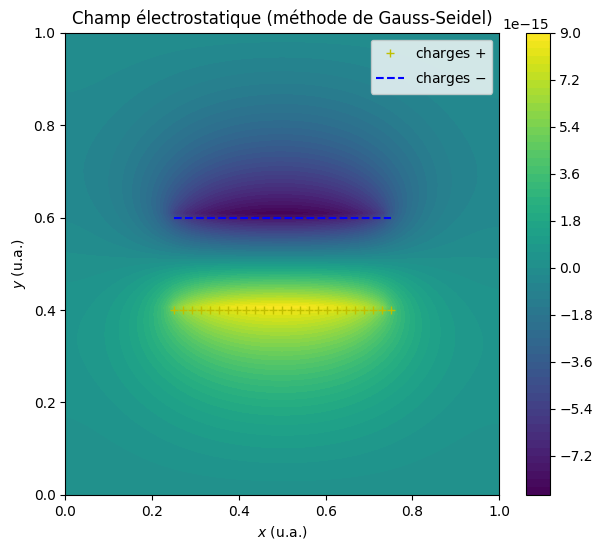

In [ ]:
# Affichage de la solution obtenue par la méthode de Gauss-Seidel

V_GS = V_Gauss_Seidel.reshape(I,J)

plt.figure(figsize = (7 ,6))
x = np.linspace(0,1,65)
y = np.linspace(0,1,65)
plt.contourf(x,y,V_GS,65)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Champ électrostatique (méthode de Gauss-Seidel)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()
plt.show()

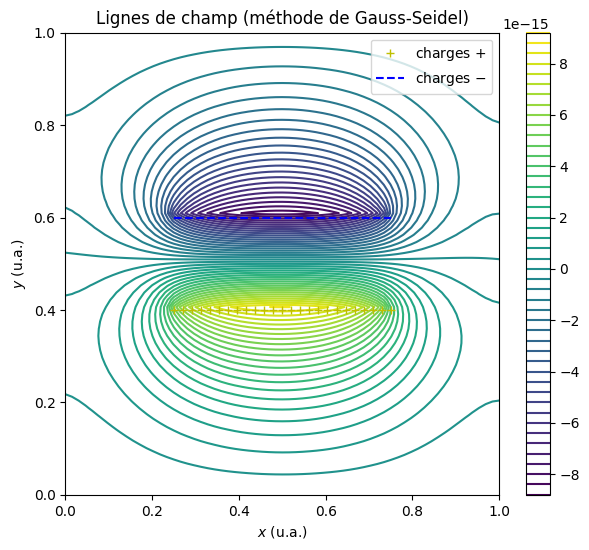

In [ ]:
# Affichage des lignes de champ

plt.figure(figsize = (7 ,6))
plt.contour(x,y,V_GS,50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Lignes de champ (méthode de Gauss-Seidel)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()
plt.show()

<ipython-input-26-c751e612bbeb>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V[i] = (b[i] - D) / A[i, i]


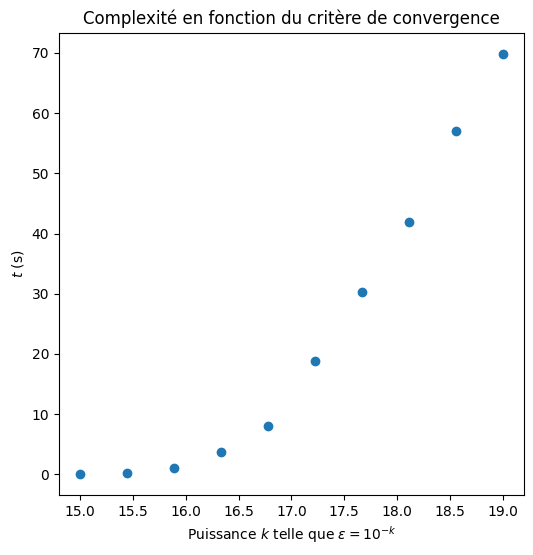

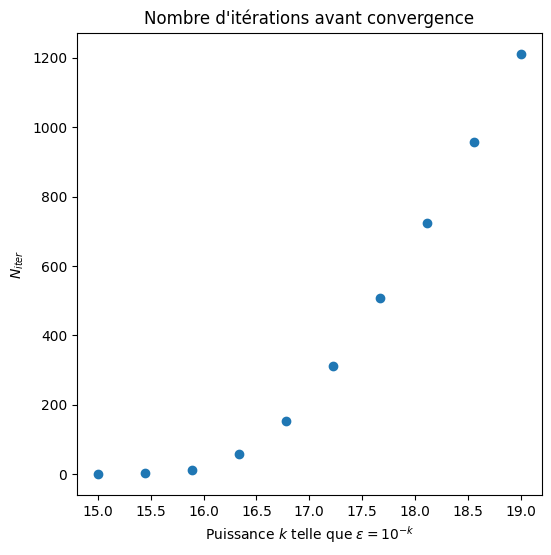

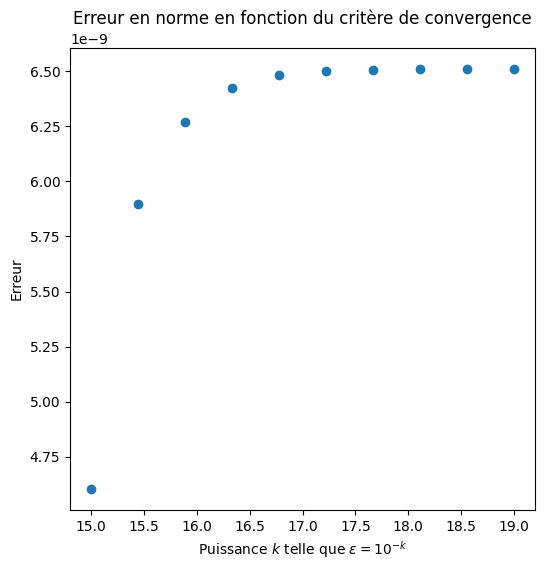

In [ ]:
# Évolution de la complexité en fonction du critère de convergence

N_iter = 5000
Temps_GS = []
Erreur_GS = []
N_GS = []
i = np.linspace(15,19,10)

for j in i:
  cvg = 10**(-j)
  start = time.time()
  Z,N_fin = Gauss_Seidel(A, b, cvg, N_iter)
  end = time.time()
  Temps_GS.append(end-start)
  N_GS.append(N_fin)
  Erreur_GS.append(np.linalg.norm(np.dot(A,Z) - b))

plt.figure(1,figsize = (6 ,6))
plt.scatter(i,Temps_GS)
plt.title('Complexité en fonction du critère de convergence')
plt.xlabel('Puissance $k$ telle que $\epsilon = 10^{-k}$')
plt.ylabel('$t$ (s)')
plt.figure(2,figsize = (6 ,6))
plt.scatter(i,N_GS)
plt.title("Nombre d'itérations avant convergence")
plt.xlabel('Puissance $k$ telle que $\epsilon = 10^{-k}$')
plt.ylabel('$N_{iter}$')
plt.figure(3,figsize = (6 ,6))
plt.scatter(i,Erreur_GS)
plt.title('Erreur en norme en fonction du critère de convergence')
plt.xlabel('Puissance $k$ telle que $\epsilon = 10^{-k}$')
plt.ylabel('Erreur')
plt.show()

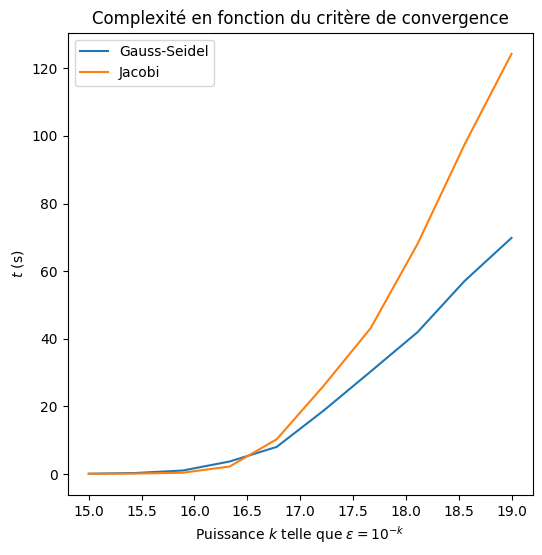

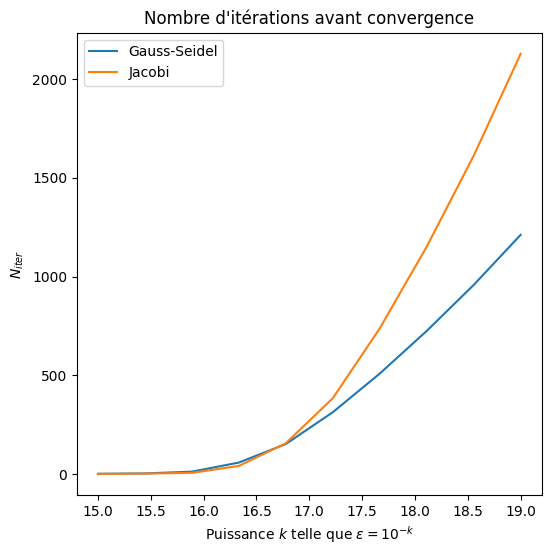

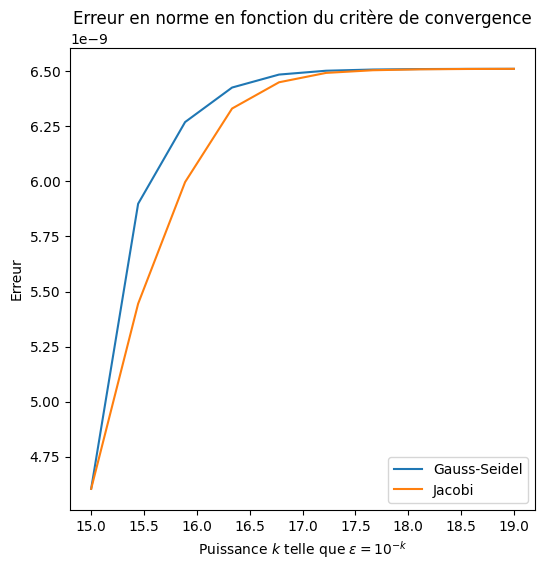

In [ ]:
# Comparaison de Jacobi et Gauss-Seidel

plt.figure(1,figsize = (6 ,6))
plt.plot(i,Temps_GS,label='Gauss-Seidel')
plt.plot(i,Temps_J,label='Jacobi')
plt.title('Complexité en fonction du critère de convergence')
plt.xlabel('Puissance $k$ telle que $\epsilon = 10^{-k}$')
plt.ylabel('$t$ (s)')
plt.legend()
plt.figure(2,figsize = (6 ,6))
plt.plot(i,N_GS,label='Gauss-Seidel')
plt.plot(i,N_J,label='Jacobi')
plt.title("Nombre d'itérations avant convergence")
plt.xlabel('Puissance $k$ telle que $\epsilon = 10^{-k}$')
plt.ylabel('$N_{iter}$')
plt.legend()
plt.figure(3,figsize = (6 ,6))
plt.plot(i,Erreur_GS,label='Gauss-Seidel')
plt.plot(i,Erreur_J,label='Jacobi')
plt.title('Erreur en norme en fonction du critère de convergence')
plt.xlabel('Puissance $k$ telle que $\epsilon = 10^{-k}$')
plt.ylabel('Erreur')
plt.legend()
plt.show()

<ipython-input-55-43cf57de1e24>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V[i] = (1 - w) * V_k[i] + (w * (b[i] - somme)) / A[i, i]


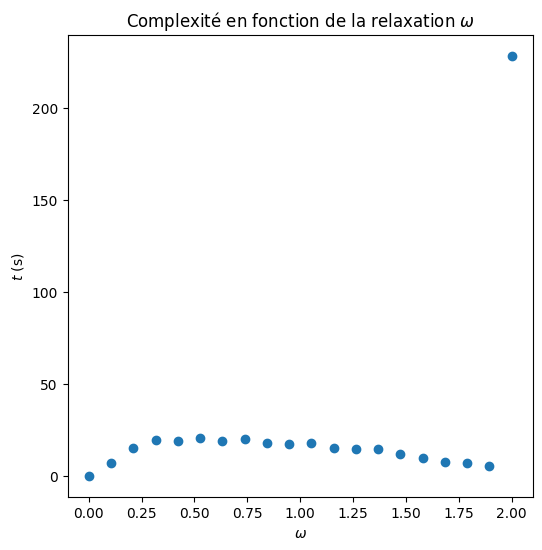

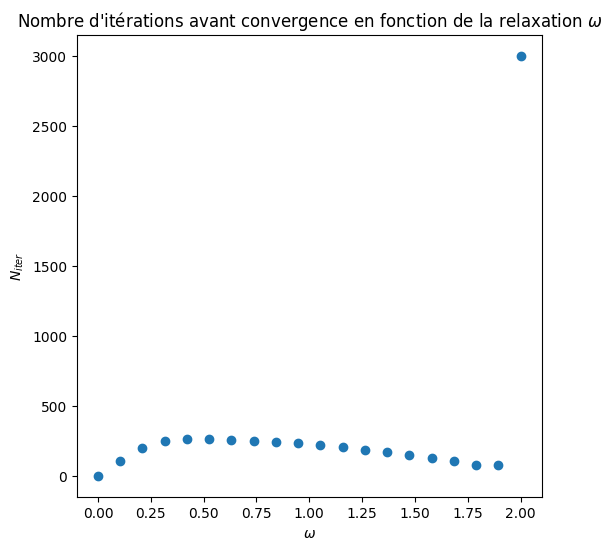

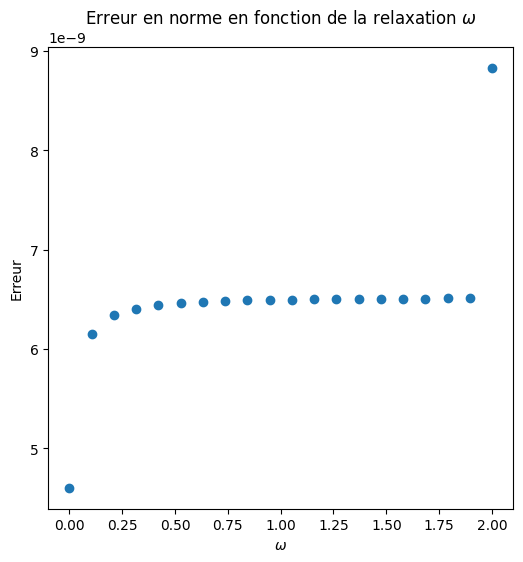

In [ ]:
# Méthode de Gauss-Seidel avec sur-relaxation

def Gauss_Seidel_relaxation(A, b, w, cvg , N_iter):
  n = len(b)
  V = np.zeros(n)  # Sera notre vecteur solution

  for k in range(N_iter):
    V_k = np.copy(V)
    for i in range(n):
      somme = np.dot(A[i, :i], V[:i]) + np.dot(A[i, i+1:], V_k[i+1:])
      V[i] = (1 - w) * V_k[i] + (w * (b[i] - somme)) / A[i, i]

    # Critère de convergence (évalué après la mise à jour complète)
    if np.linalg.norm(V - V_k, ord=np.inf) < cvg:
      return V, k + 1

  return V,N_iter

start = time.time()
cvg = 1e-17 ### phénomène très intéressant à 10e-16 (avant on a des exponentielles) et 10e-17
N_iter = 3000
W = np.linspace(0,2,20)
Temps_GSr = []
Erreur_GSr = []
N_GSr = []
for w in W:
  start = time.time()
  a,c = Gauss_Seidel_relaxation(A,b,w,cvg,N_iter)
  end = time.time()
  Temps_GSr.append(end-start)
  N_GSr.append(c)
  Erreur_GSr.append(np.linalg.norm(np.dot(A,a) - b))

plt.figure(1,figsize = (6 ,6))
plt.scatter(W,Temps_GSr)
plt.title('Complexité en fonction de la relaxation $\omega$')
plt.xlabel('$\omega$')
plt.ylabel('$t$ (s)')
plt.figure(2,figsize = (6 ,6))
plt.scatter(W,N_GSr)
plt.title("Nombre d'itérations avant convergence en fonction de la relaxation $\omega$")
plt.xlabel('$\omega$')
plt.ylabel('$N_{iter}$')
plt.figure(3,figsize = (6 ,6))
plt.scatter(W,Erreur_GSr)
plt.title('Erreur en norme en fonction de la relaxation $\omega$')
plt.xlabel('$\omega$')
plt.ylabel('Erreur')
plt.show()

<ipython-input-55-43cf57de1e24>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V[i] = (1 - w) * V_k[i] + (w * (b[i] - somme)) / A[i, i]


Le temps de calcul par la méthode de Gauss-Seidel avec relaxation est de 5.678440809249878 s au bout de 82 itérations pour une tolérance de 1e-17 .
L'erreur en norme par la méthode de Gauss-Seidel avec relaxation est de 6.511450574843645e-09 .


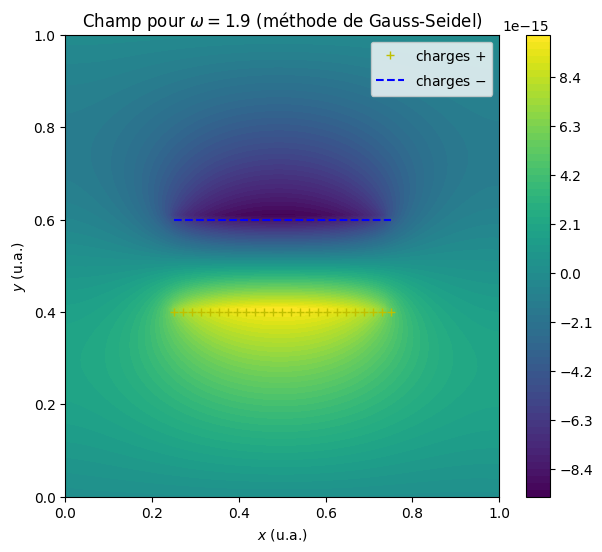

In [ ]:
start = time.time()
cvg = 1e-17
N_iter = 3000
w = 1.9
V_Gauss_Seidel_r,N_GSr = Gauss_Seidel_relaxation(A,b,w,cvg,N_iter) ## phénomènes intéressants à 0.2 et stabilisation à 0.5
end = time.time()
t_GSr = end-start
erreur_GSr = np.linalg.norm(np.dot(A,V_Gauss_Seidel_r) - b)
print('Le temps de calcul par la méthode de Gauss-Seidel avec relaxation est de', t_GSr,'s au bout de',N_GSr,'itérations pour une tolérance de',cvg,'.')
print("L'erreur en norme par la méthode de Gauss-Seidel avec relaxation est de", erreur_GSr,'.')

V_GSr = V_Gauss_Seidel_r.reshape(I,J)

plt.figure(figsize = (7 ,6))
x = np.linspace(0,1,65)
y = np.linspace(0,1,65)
plt.contourf(x,y,V_GSr,65)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Champ pour $\omega = $'+ str(w) +' (méthode de Gauss-Seidel)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()
plt.show()

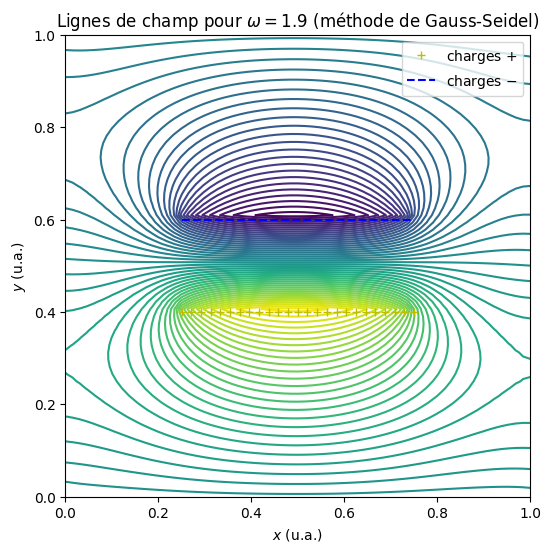

In [ ]:
## Affichage des lignes de champ

plt.figure(figsize = (6 ,6))
plt.contour(x,y,V_GSr,50)
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Lignes de champ pour $\omega=1.9$ (méthode de Gauss-Seidel)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()
plt.show()

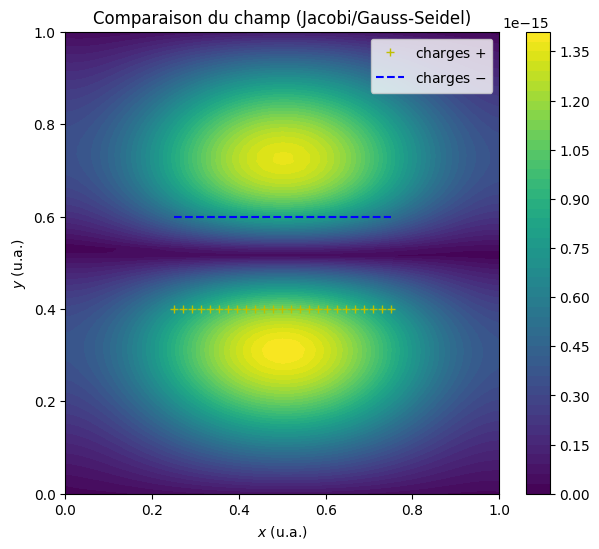

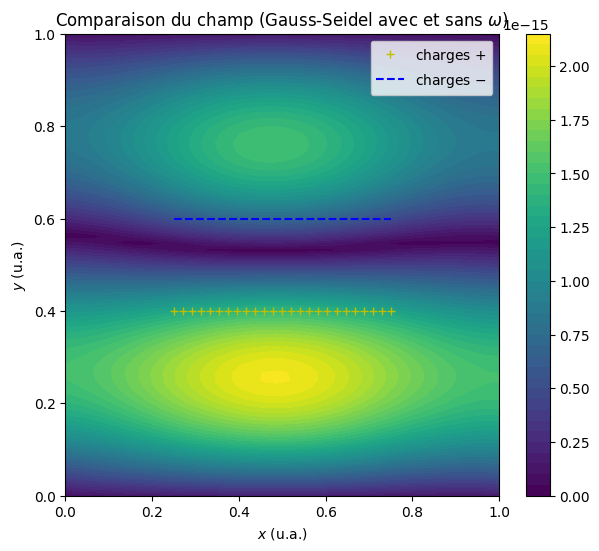

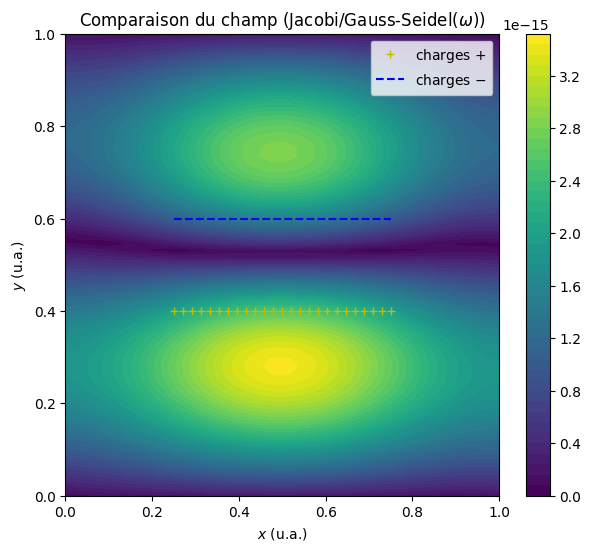

In [ ]:
plt.figure(figsize = (7 ,6))
plt.contourf(x,y,abs(V_J-V_GS),50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Comparaison du champ (Jacobi/Gauss-Seidel)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()

plt.figure(figsize = (7 ,6))
plt.contourf(x,y,abs(V_GS-V_GSr),50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Comparaison du champ (Gauss-Seidel avec et sans $\omega$)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()

plt.figure(figsize = (7 ,6))
plt.contourf(x,y,abs(V_J-V_GSr),50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Comparaison du champ (Jacobi/Gauss-Seidel($\omega$))')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()

plt.show()

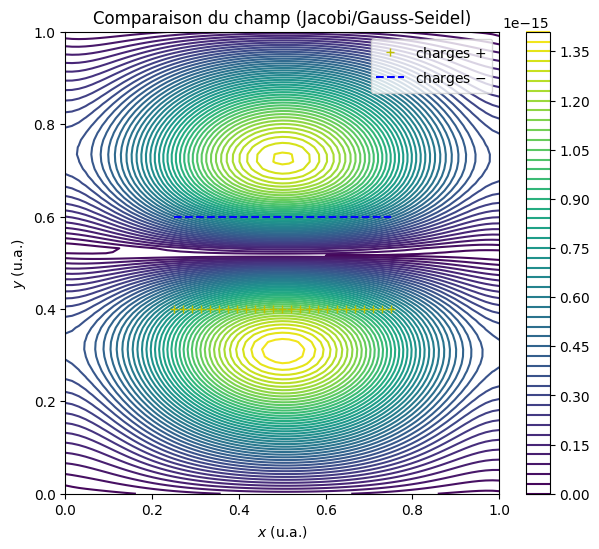

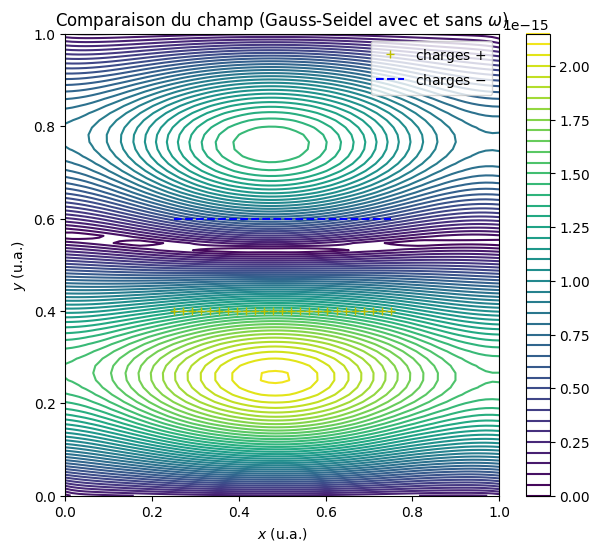

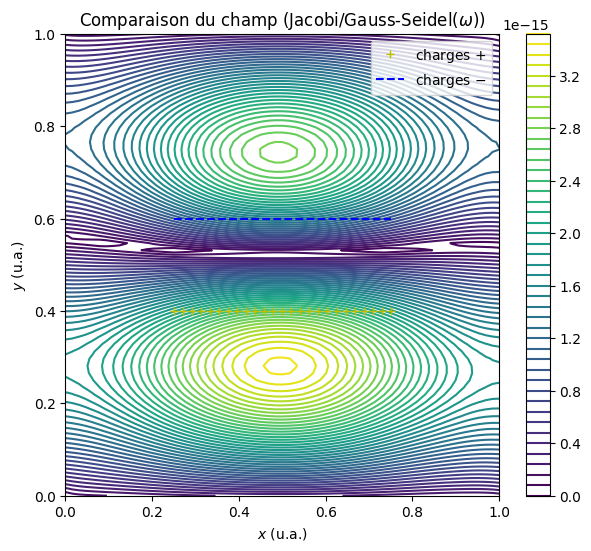

In [ ]:
plt.figure(figsize = (7 ,6))
plt.contour(x,y,abs(V_J-V_GS),50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Comparaison du champ (Jacobi/Gauss-Seidel)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()

plt.figure(figsize = (7 ,6))
plt.contour(x,y,abs(V_GS-V_GSr),50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Comparaison du champ (Gauss-Seidel avec et sans $\omega$)')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()

plt.figure(figsize = (7 ,6))
plt.contour(x,y,abs(V_J-V_GSr),50)
plt.colorbar()
plt.plot(x_c ,y_c[0], 'y+',label='charges $+$')
plt.plot(x_c ,y_c[1], 'b--',label='charges $-$')
plt.title('Comparaison du champ (Jacobi/Gauss-Seidel($\omega$))')
plt.xlabel('$x$ (u.a.)')
plt.ylabel('$y$ (u.a.)')
plt.legend()

plt.show()

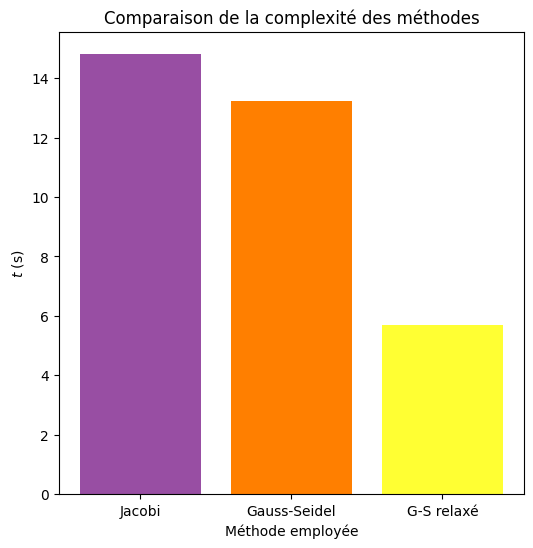

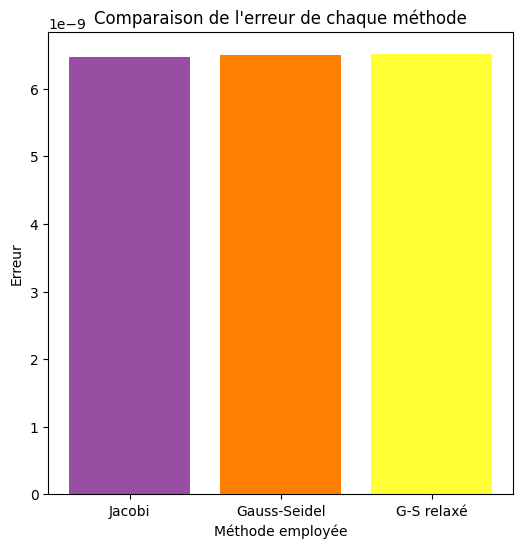

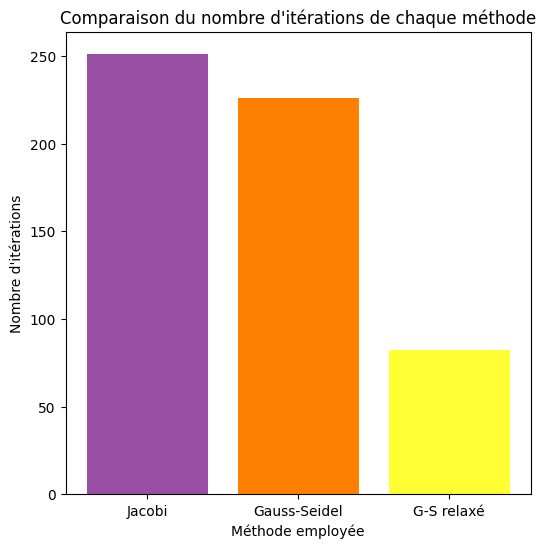

In [ ]:
## on fixe une convergence à 10e-17, un nombre d'itérations max de 3000

labels = ['Gauss', 'creux', 'solve','Jacobi', 'Gauss-Seidel', 'G-S relaxé']
T = [t_Gauss,t_creux,t_solve,t_Jacobi,t_Gauss_Seidel,t_GSr]
E = [erreur_Gauss,erreur_creux,erreur_solve,erreur_Jacobi,erreur_Gauss_Seidel,erreur_GSr]
I = [N_Jacobi,N_Gauss_Seidel,N_GSr]

# Utilisation de la palette de couleurs "Set1"
palette = plt.get_cmap("Set1")

plt.figure(1,figsize = (6 ,6))
plt.bar([labels[i] for i in range(3,6)],[T[i] for i in range(3,6)], color=[palette(i+3) for i in range(len(labels))])
plt.title('Comparaison de la complexité des méthodes')
plt.xlabel('Méthode employée')
plt.ylabel('$t$ (s)')

plt.figure(2,figsize = (6 ,6))
plt.bar([labels[i] for i in range(3,6)],[E[i] for i in range(3,6)], color=[palette(i+3) for i in range(len(labels))])
plt.title("Comparaison de l'erreur de chaque méthode")
plt.xlabel('Méthode employée')
plt.ylabel('Erreur')

plt.figure(3,figsize = (6 ,6))
plt.bar([labels[i] for i in range(3,6)],I, color=[palette(i+3) for i in range(len(labels))])
plt.title("Comparaison du nombre d'itérations de chaque méthode")
plt.xlabel('Méthode employée')
plt.ylabel("Nombre d'itérations")

plt.show()

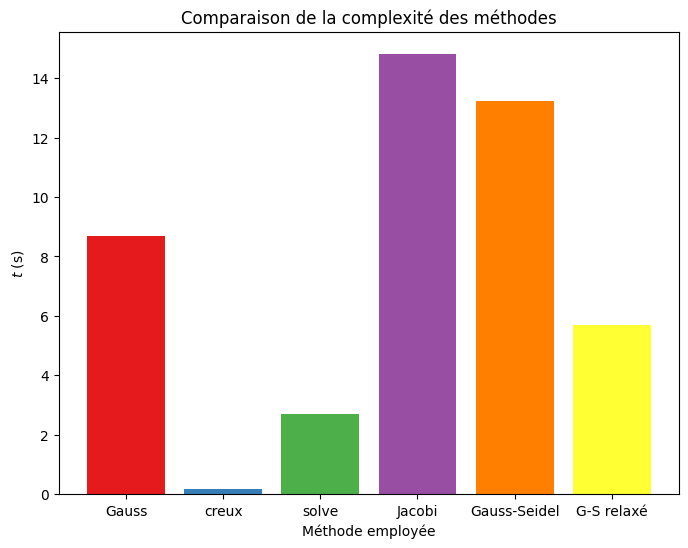

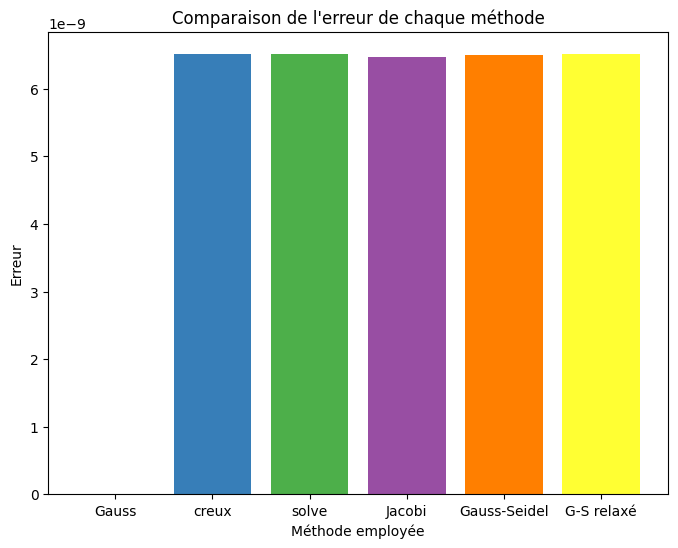

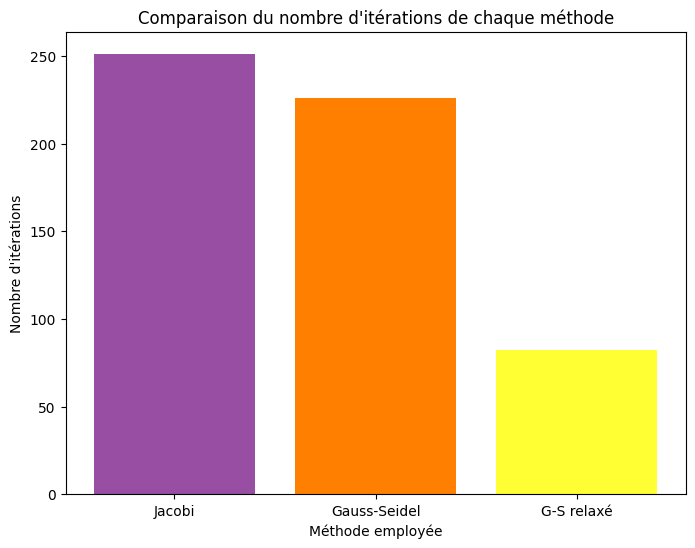

In [ ]:
## on fixe une convergence à 10e-17, un nombre d'itérations max de 3000

labels = ['Gauss', 'creux', 'solve','Jacobi', 'Gauss-Seidel', 'G-S relaxé']
T = [t_Gauss,t_creux,t_solve,t_Jacobi,t_Gauss_Seidel,t_GSr]
E = [erreur_Gauss,erreur_creux,erreur_solve,erreur_Jacobi,erreur_Gauss_Seidel,erreur_GSr]
I = [N_Jacobi,N_Gauss_Seidel,N_GSr]

# Utilisation de la palette de couleurs "Set1"
palette = plt.get_cmap("Set1")

plt.figure(1,figsize = (8 ,6))
plt.bar(labels,T, color=[palette(i) for i in range(len(labels))])
plt.title('Comparaison de la complexité des méthodes')
plt.xlabel('Méthode employée')
plt.ylabel('$t$ (s)')

plt.figure(2,figsize = (8 ,6))
plt.bar(labels,E, color=[palette(i) for i in range(len(labels))])
plt.title("Comparaison de l'erreur de chaque méthode")
plt.xlabel('Méthode employée')
plt.ylabel('Erreur')

plt.figure(3,figsize = (8 ,6))
plt.bar([labels[i] for i in range(3,6)],I, color=[palette(i+3) for i in range(len(labels))])
plt.title("Comparaison du nombre d'itérations de chaque méthode")
plt.xlabel('Méthode employée')
plt.ylabel("Nombre d'itérations")

plt.show()